
                                                                           
   # <center>Covid-19 in Spain </center>               

 # <center>by Ida Tateo</center>



1. Define the Research problem and associated questions.
2. Analyze the data by descriptive statistics and graphical visualization.
3. Prepare the data by using relevant preprocessing transformations, data cleaning, 
    data standardization, deaing with null and outlier values.

    

## 1. Define the Research problem and questions

**Research Questions:**  

    1.Create Sand Layer Charts to detect patterns of Covid-19 trends in Spain from the beginning of the pandemic to the end  of 2020.

**Data Source:**
     I downloaded the dataset of Covid-19 in Spain by region from Kaggle.


In [15]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns



## 2. Analyze the data using descriptive statistics and graphical visualizations.

In [17]:
# Filter warnings 
import warnings
warnings.filterwarnings('ignore')

import build_spain_ccaa_2020_cumulative

# Run the main function from the script
build_spain_ccaa_2020_cumulative.main()

# Read in the raw dataset, print the shape and first 5 rows.
covid_spain_cases = pd.read_csv('ccaa_covid19_casos_long.csv')
print(covid_spain_cases.shape)
print(covid_spain_cases.head())

covid_spain_deaths = pd.read_csv('ccaa_covid19_fallecidos_long.csv')
print(covid_spain_deaths.shape)
print(covid_spain_deaths.head())

spain_covid19_long = pd.read_csv('spain_ccaa_covid19_2020_cumulative_long.csv')
print(spain_covid19_long.shape)
print(spain_covid19_long.head())

#spain_covid19_wide_cases = pd.read_csv('spain_ccaa_covid19_2020_cumulative_wide_cases.csv')
#print(spain_covid19_wide_cases.shape)
#print(spain_covid19_wide_cases.head())

#spain_covid19_wide_deaths = pd.read_csv('spain_ccaa_covid19_2020_cumulative_wide_deaths.csv')
#print(spain_covid19_wide_deaths.shape)
#print(spain_covid19_wide_deaths.head())


✅ Wrote:
 - spain_ccaa_covid19_2020_cumulative_long.csv
 - spain_ccaa_covid19_2020_cumulative_wide_cases.csv
 - spain_ccaa_covid19_2020_cumulative_wide_deaths.csv
(1729, 4)
        fecha  cod_ine       CCAA  total
0  2020-02-21        1  Andalucía      0
1  2020-02-22        1  Andalucía      0
2  2020-02-23        1  Andalucía      0
3  2020-02-24        1  Andalucía      0
4  2020-02-25        1  Andalucía      0
(1558, 4)
        fecha  cod_ine       CCAA  total
0  2020-03-04        1  Andalucía      0
1  2020-03-05        1  Andalucía      0
2  2020-03-06        1  Andalucía      0
3  2020-03-07        1  Andalucía      0
4  2020-03-08        1  Andalucía      0
(7320, 4)
         date     region  cum_cases  cum_deaths
0  2020-01-01  Andalucía          0           0
1  2020-01-02  Andalucía          0           0
2  2020-01-03  Andalucía          0           0
3  2020-01-04  Andalucía          0           0
4  2020-01-05  Andalucía          0           0


In [18]:
# Print the datatypes which are keys.
types = covid_spain_cases.dtypes
print(types)
print("Keys of Covid Cases in Spain dataset:\n", covid_spain_cases.keys())

types = covid_spain_deaths.dtypes
print(types)
print("Keys of Covid Deaths in Spain dataset:\n", covid_spain_deaths.keys())


fecha      object
cod_ine     int64
CCAA       object
total       int64
dtype: object
Keys of Covid Cases in Spain dataset:
 Index(['fecha', 'cod_ine', 'CCAA', 'total'], dtype='object')
fecha      object
cod_ine     int64
CCAA       object
total       int64
dtype: object
Keys of Covid Deaths in Spain dataset:
 Index(['fecha', 'cod_ine', 'CCAA', 'total'], dtype='object')


(366, 20)
region      Andalucía  Aragón  Asturias  Baleares  C. Valenciana  Canarias  \
date                                                                         
2020-01-01          0       0         0         0              0         0   
2020-01-02          0       0         0         0              0         0   
2020-01-03          0       0         0         0              0         0   
2020-01-04          0       0         0         0              0         0   
2020-01-05          0       0         0         0              0         0   

region      Cantabria  Castilla La Mancha  Castilla y León  Cataluña  Ceuta  \
date                                                                          
2020-01-01          0                   0                0         0      0   
2020-01-02          0                   0                0         0      0   
2020-01-03          0                   0                0         0      0   
2020-01-04          0                   0       

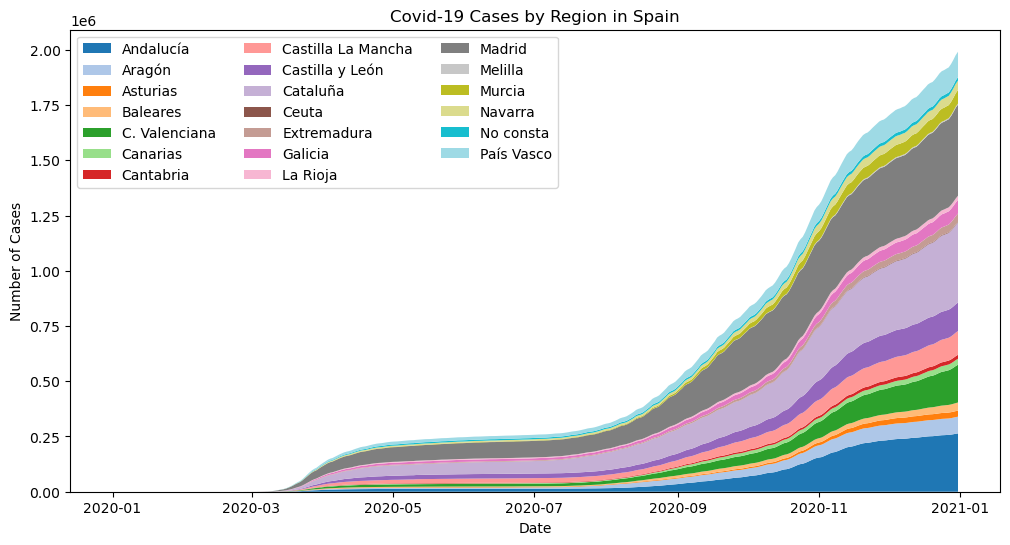

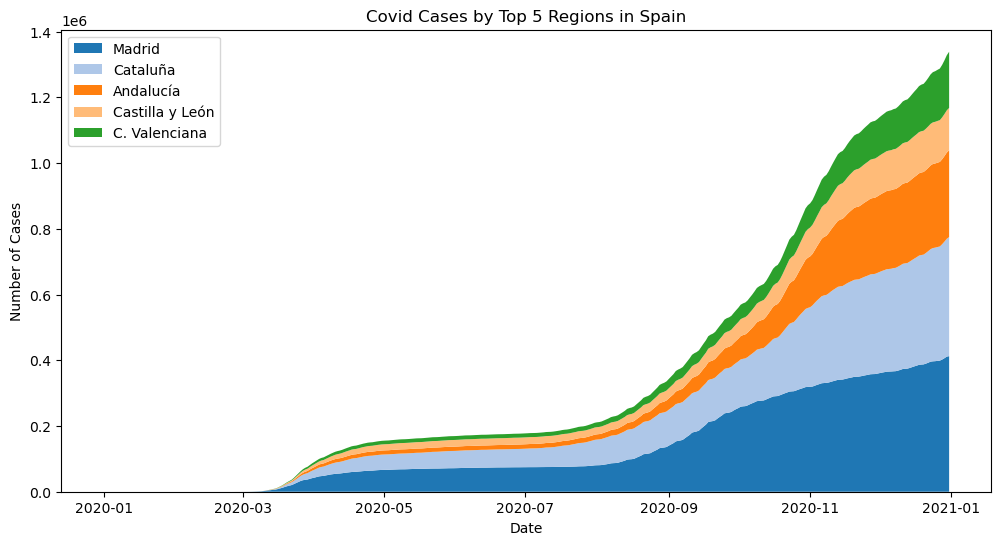

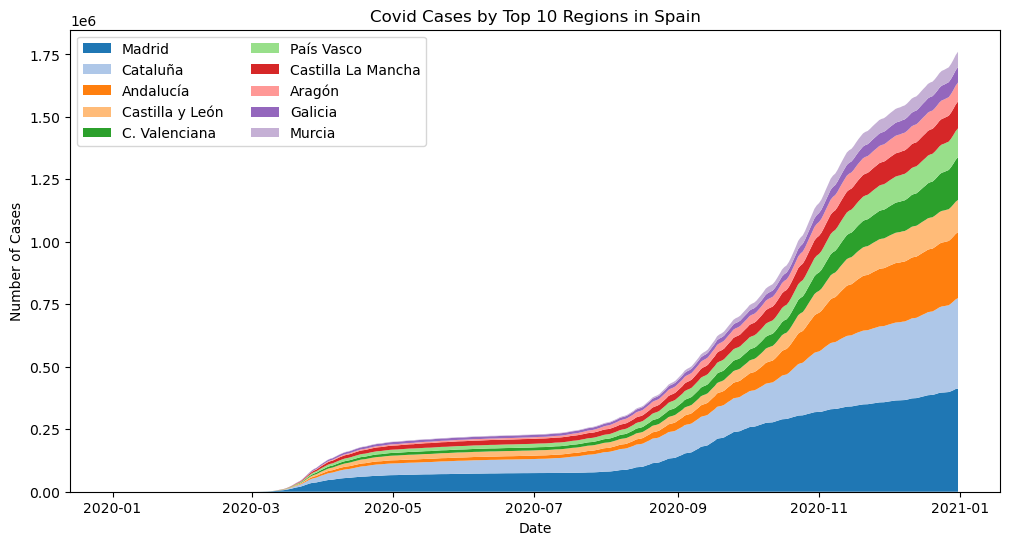

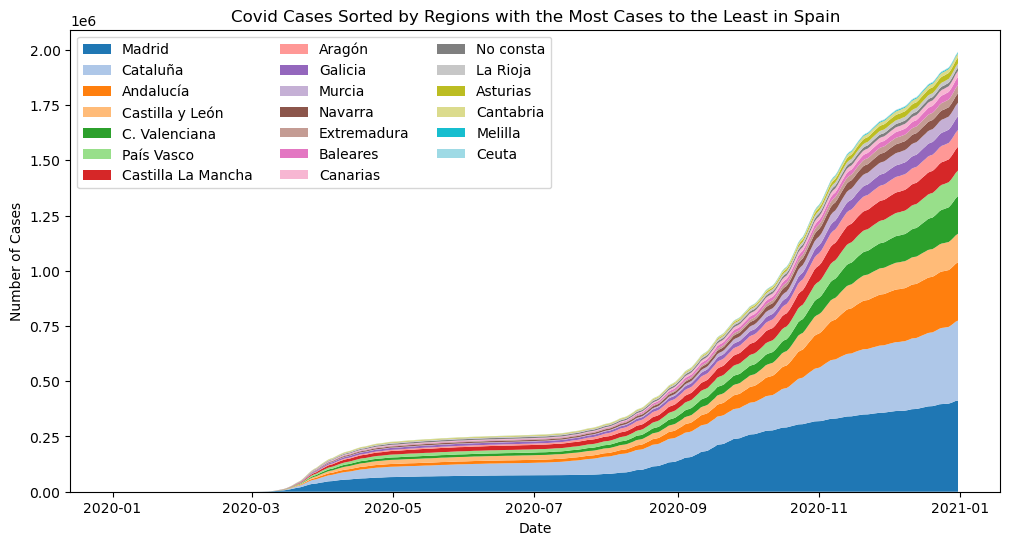

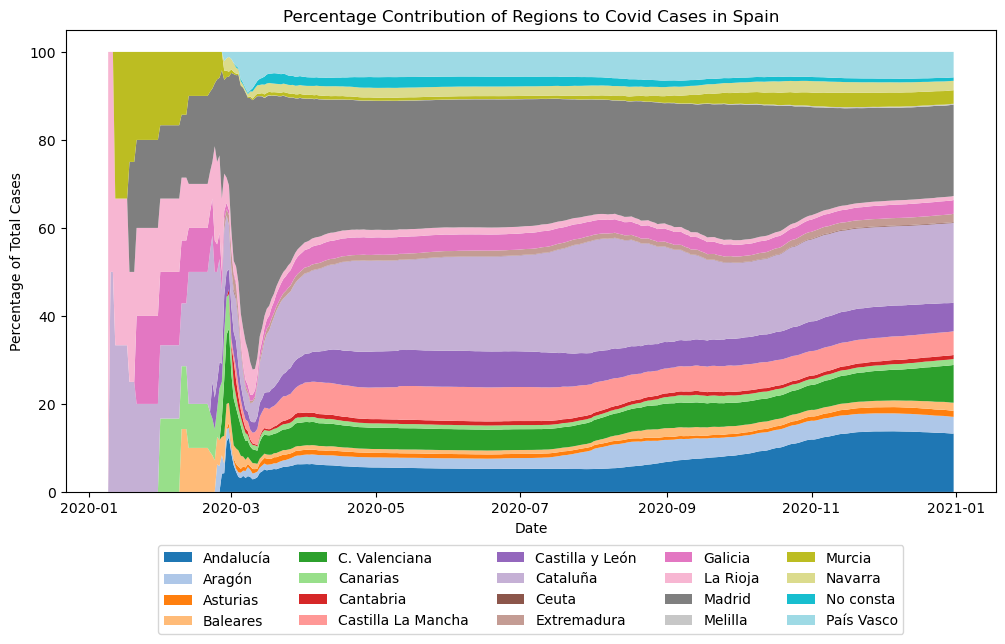

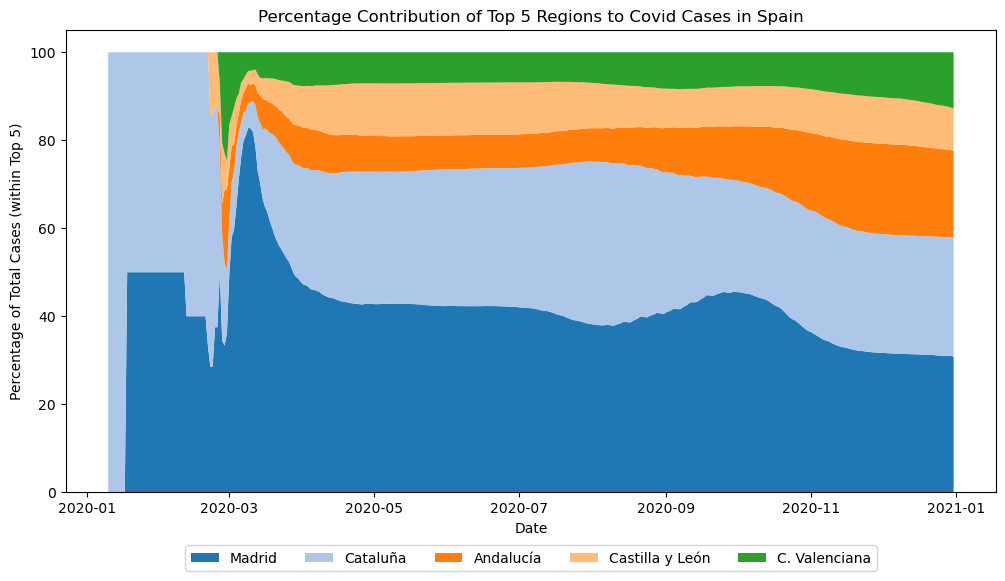

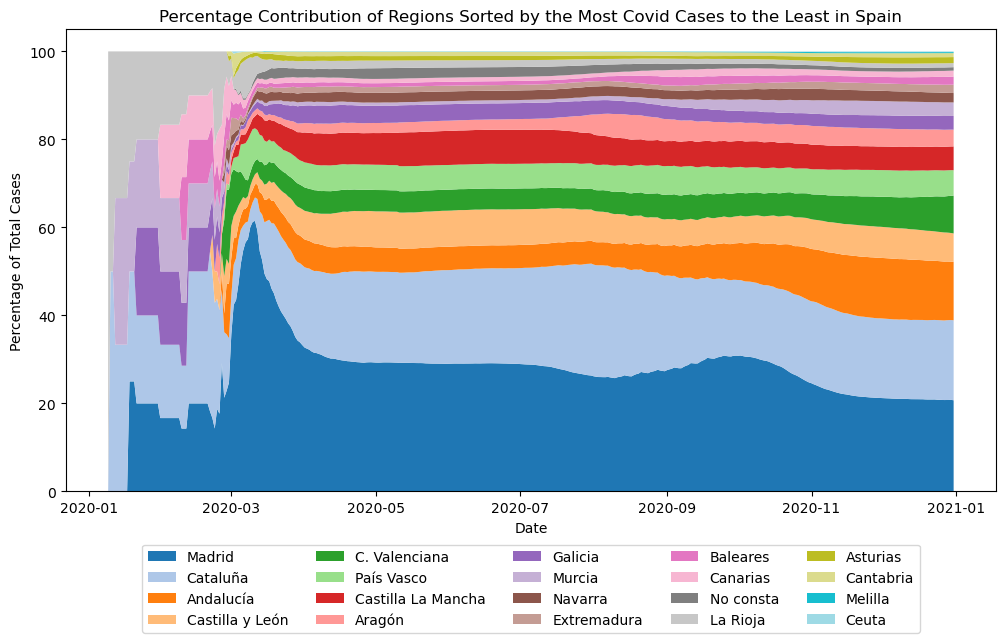

In [20]:

# create a covid dataset with date, region, and cases
#covid_spain_cases = covid_spain_cases[['fecha', 'CCAA', 'total']]

#covid_spain_cases.columns = ["date", "region", "cum_cases"]

# pivot to wide format (date x region table)
spain_covid19_cases = spain_covid19_long.pivot(index="date",columns="region",values="cum_cases")

# change date index to datetime.
spain_covid19_cases.index=pd.to_datetime(spain_covid19_cases.index)

print(spain_covid19_cases.shape)
print(spain_covid19_cases.head())
print(spain_covid19_cases.tail())
print(spain_covid19_cases.describe().T)

# pick a colormap and generate enough distinct colors
colors = cm.tab20(np.linspace(0, 1, spain_covid19_cases.shape[1]))

#colors = sns.color_palette("Set2", n_colors=spain_covid19_cases.shape[1])

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(spain_covid19_cases.index,
              spain_covid19_cases.T,
              labels=spain_covid19_cases.columns,
              colors=colors)
plt.title("Covid-19 Cases by Region in Spain")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)

#title = "COVID-19 Cases by Region"
#plt.title(title)
plt.savefig("spain_cases_fig1.png", dpi=300, bbox_inches="tight")
#plots.append(("cases.png", title))
#plt.close()
plt.show()


# select the top 5 regions in Spain with the most cases

# find the total cases per region
region_totals=spain_covid19_cases.sum().sort_values(ascending=False)

# select the top 5 regions
top5_regions=region_totals.head(5).index

# filter dataframe to those regions only
top5_data=spain_covid19_cases[top5_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top5_data.index,
              top5_data.T,
              labels=top5_data.columns,
              colors=colors)
plt.title("Covid Cases by Top 5 Regions in Spain")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.savefig("spain_cases_fig2.png", dpi=300, bbox_inches="tight")
plt.show()

# select top 10 regions in Spain with the most cases

# select the top 10 regions
top10_regions=region_totals.head(10).index

# filter dataframe to those regions only
top10_data=spain_covid19_cases[top10_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top10_data.index,
              top10_data.T,
              labels=top10_data.columns,
              colors=colors)
plt.title("Covid Cases by Top 10 Regions in Spain")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=2)
plt.savefig("spain_cases_fig3.png", dpi=300, bbox_inches="tight")
plt.show()

# sort the regions in Spain with the most cases to the least

# select sorted regions
sorted_regions=region_totals.head(20).index

# filter dataframe to sorted regions
sorted_data=spain_covid19_cases[sorted_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(sorted_data.index,
              sorted_data.T,
              labels=sorted_data.columns,
              colors=colors)
plt.title("Covid Cases Sorted by Regions with the Most Cases to the Least in Spain")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.savefig("spain_cases_fig4.png", dpi=300, bbox_inches="tight")
plt.show()

# convert to percentages per day
covid_percent = spain_covid19_cases.div(spain_covid19_cases.sum(axis=1), axis=0) * 100

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(covid_percent.index,
              covid_percent.T,
              labels=covid_percent.columns,
              colors=colors)
plt.title("Percentage Contribution of Regions to Covid Cases in Spain")
plt.ylabel("Percentage of Total Cases")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.savefig("spain_cases_fig5.png", dpi=300, bbox_inches="tight")
plt.show()

# select the top N regions
N = 5
region_totals=spain_covid19_cases.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = spain_covid19_cases[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns,
              colors=colors)

plt.title(f"Percentage Contribution of Top {N} Regions to Covid Cases in Spain")
plt.ylabel("Percentage of Total Cases (within Top 5)")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.savefig("spain_cases_fig6.png", dpi=300, bbox_inches="tight")
plt.show()

# select the top N regions
N = 20
region_totals=spain_covid19_cases.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = spain_covid19_cases[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns,
              colors=colors)

plt.title("Percentage Contribution of Regions Sorted by the Most Covid Cases to the Least in Spain")
plt.ylabel("Percentage of Total Cases")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.savefig("spain_cases_fig7.png", dpi=300, bbox_inches="tight")
plt.show()


(366, 20)
region      Andalucía  Aragón  Asturias  Baleares  C. Valenciana  Canarias  \
date                                                                         
2020-01-01          0       0         0         0              0         0   
2020-01-02          0       0         0         0              0         0   
2020-01-03          0       0         0         0              0         0   
2020-01-04          0       0         0         0              0         0   
2020-01-05          0       0         0         0              0         0   

region      Cantabria  Castilla La Mancha  Castilla y León  Cataluña  Ceuta  \
date                                                                          
2020-01-01          0                   0                0         0      0   
2020-01-02          0                   0                0         0      0   
2020-01-03          0                   0                0         0      0   
2020-01-04          0                   0       

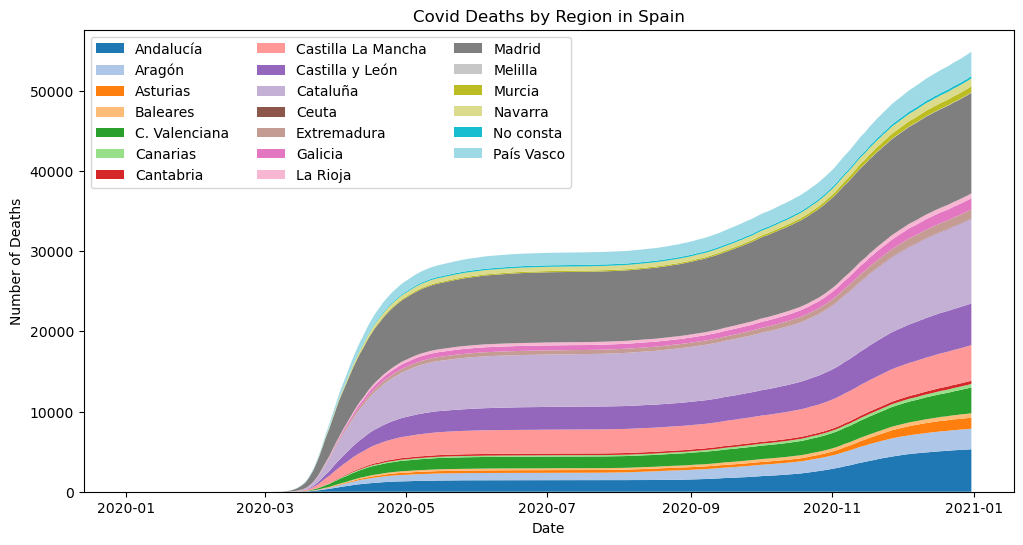

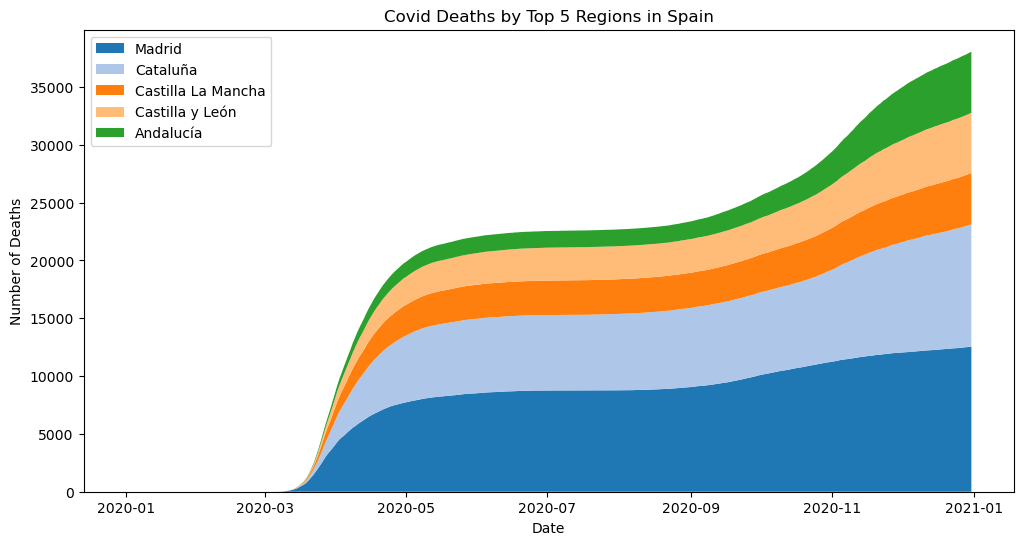

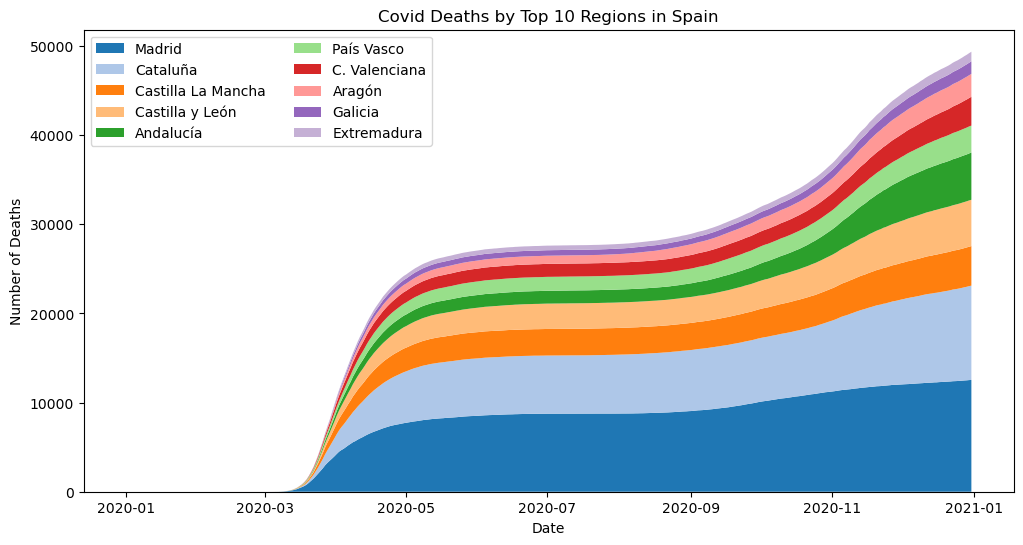

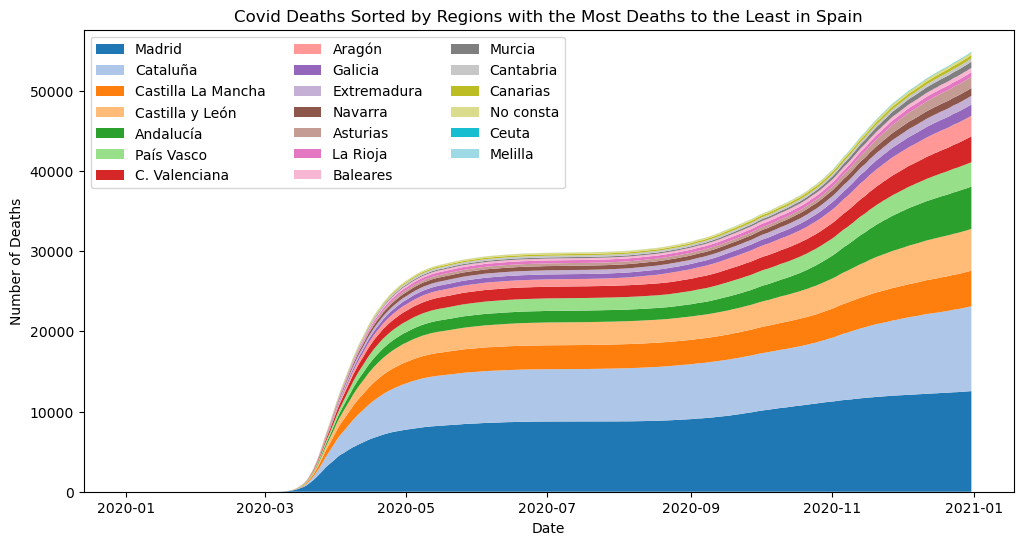

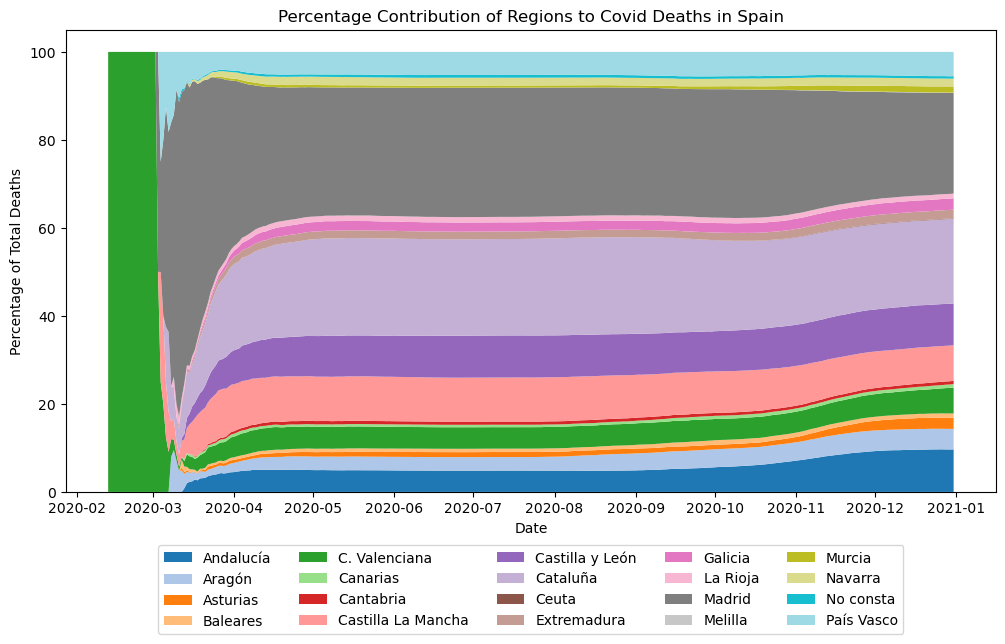

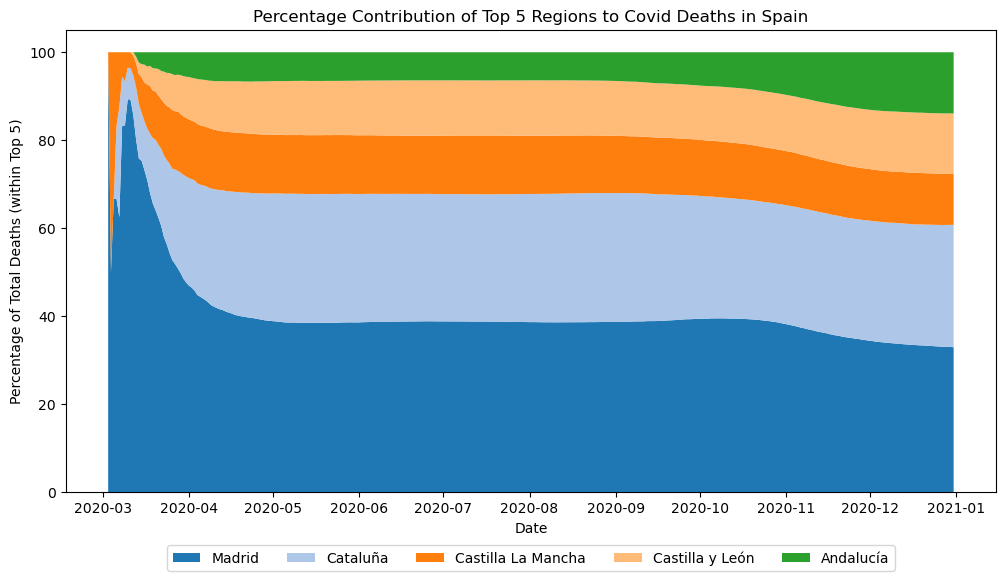

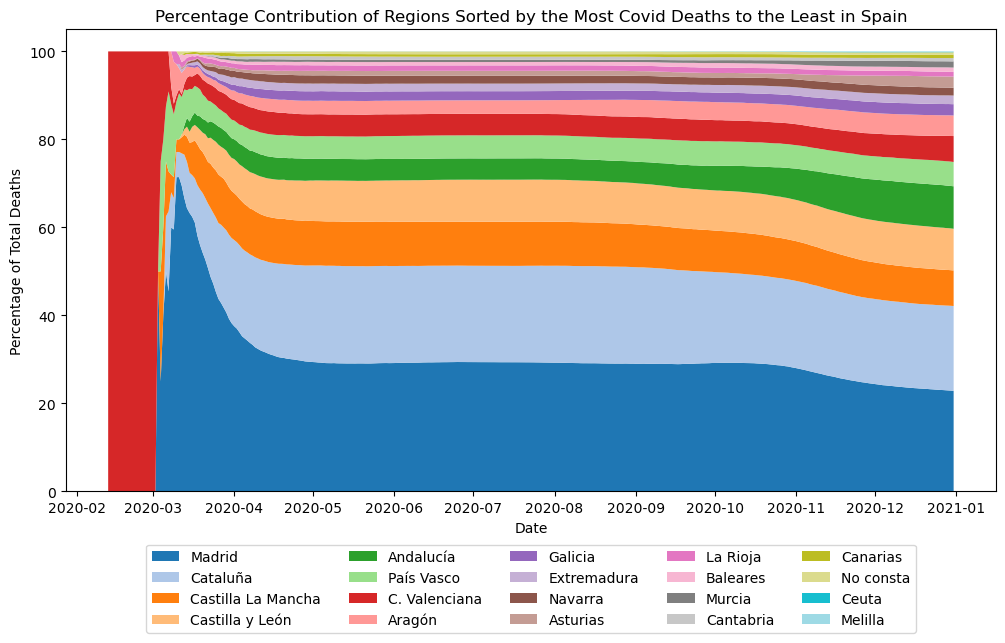

In [21]:
# create a covid dataset with date, region, and deaths
#covid_spain_deaths = covid_spain_deaths[['fecha', 'CCAA', 'total']]

#covid_spain_deaths.columns = ["date", "region", "totaldeaths"]

# pivot to wide format (date x region table)
spain_covid19_deaths = spain_covid19_long.pivot(index="date",columns="region",values="cum_deaths")

# change date index to datetime.
spain_covid19_deaths.index=pd.to_datetime(spain_covid19_deaths.index)

print(spain_covid19_deaths.shape)
print(spain_covid19_deaths.head())
print(spain_covid19_deaths.tail())
print(spain_covid19_deaths.describe().T)

# pick a colormap and generate enough distinct colors
colors = cm.tab20(np.linspace(0, 1, spain_covid19_deaths.shape[1]))

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(spain_covid19_deaths.index,
              spain_covid19_deaths.T,
              labels=spain_covid19_deaths.columns,
              colors=colors)
plt.title("Covid Deaths by Region in Spain")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.savefig("spain_deaths_fig1.png", dpi=300, bbox_inches="tight")
plt.show()

# select the top 5 regions in Spain with the most deaths

# find the total deaths per region
region_totals=spain_covid19_deaths.sum().sort_values(ascending=False)

# select the top 5 regions
top5_regions=region_totals.head(5).index

# filter dataframe to those regions only
top5_data=spain_covid19_deaths[top5_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top5_data.index,
              top5_data.T,
              labels=top5_data.columns,
              colors=colors)
plt.title("Covid Deaths by Top 5 Regions in Spain")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.savefig("spain_deaths_fig2.png", dpi=300, bbox_inches="tight")
plt.show()

# select top 10 regions in Spain with the most deaths

# select the top 10 regions
top10_regions=region_totals.head(10).index

# filter dataframe to those regions only
top10_data=spain_covid19_deaths[top10_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top10_data.index,
              top10_data.T,
              labels=top10_data.columns,
              colors=colors)
plt.title("Covid Deaths by Top 10 Regions in Spain")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=2)
plt.savefig("spain_deaths_fig3.png", dpi=300, bbox_inches="tight")
plt.show()

# sort the regions in Spain with the most deaths to the least

# select sorted regions
sorted_regions=region_totals.head(20).index

# filter dataframe to sorted regions
sorted_data=spain_covid19_deaths[sorted_regions]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(sorted_data.index,
              sorted_data.T,
              labels=sorted_data.columns,
              colors=colors)
plt.title("Covid Deaths Sorted by Regions with the Most Deaths to the Least in Spain")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.savefig("spain_deaths_fig4.png", dpi=300, bbox_inches="tight")
plt.show()

# convert to percentages per day
covid_percent_deaths = spain_covid19_deaths.div(spain_covid19_deaths.sum(axis=1), axis=0) * 100

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(covid_percent_deaths.index,
              covid_percent_deaths.T,
              labels=covid_percent_deaths.columns,
              colors=colors)
plt.title("Percentage Contribution of Regions to Covid Deaths in Spain")
plt.ylabel("Percentage of Total Deaths")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.savefig("spain_deaths_fig5.png", dpi=300, bbox_inches="tight")
plt.show()

# select the top N regions
N = 5
region_totals=spain_covid19_deaths.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = spain_covid19_deaths[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns,
              colors=colors)

plt.title(f"Percentage Contribution of Top {N} Regions to Covid Deaths in Spain")
plt.ylabel("Percentage of Total Deaths (within Top 5)")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.savefig("spain_deaths_fig6.png", dpi=300, bbox_inches="tight")
plt.show()

# select the top N regions
N = 20
region_totals=spain_covid19_deaths.sum().sort_values(ascending=False)
topN_regions =region_totals.head(N).index

# Filter only top N regions
topN_percent = spain_covid19_deaths[topN_regions]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns,
              colors=colors)

plt.title("Percentage Contribution of Regions Sorted by the Most Covid Deaths to the Least in Spain")
plt.ylabel("Percentage of Total Deaths")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.savefig("spain_deaths_fig7.png", dpi=300, bbox_inches="tight")
plt.show()
